# Class-DIII Monitored Majorana Chain (Gaussian backend)

Reproduces Fig. 1b of H. Pan, H. Shapourian, C.-M. Jian, *Topological Modes in Monitored Quantum Dynamics*, [Phys. Rev. B **112**, 144301 (2025)](https://doi.org/10.1103/r8mr-zbx1), [arXiv:2411.04191](https://arxiv.org/abs/2411.04191).

**Circuit** (paper's Fig. 1a): brickwork on a periodic ring of $L$ Majoranas (`site_type="Majorana"`, one Majorana $\gamma_i$ per site). One time step = two half-layers:

1. **Odd links** $(\gamma_1\gamma_2), (\gamma_3\gamma_4), \dots$ — with probability $p$ measure the bond parity $i\gamma_i\gamma_{i+1}$; otherwise apply a Haar-random $SO(2)$ rotation.
2. **Even links** $(\gamma_2\gamma_3), \dots, (\gamma_L\gamma_1)$ — same, with measurement probability $1-p$.

The staggering $p_{\rm odd}=p$, $p_{\rm even}=1-p$ interpolates between two topologically distinct area-law dimerized phases, with a critical phase in between ($0.4 \lesssim p \lesssim 0.6$). Order parameter: shift-averaged antipodal-quarter mutual information $I(A,B)$.

## Setup

In [1]:
using Pkg; Pkg.activate(dirname(@__DIR__))
using QuantumCircuitsMPS
using Printf
using Statistics
using Plots
using ProgressMeter
using Luxor
default(fmt=:png)   # PNG-only plot outputs keep this notebook well under 1 MB

  Activating project at `~/personal/QuantumCircuitsMPS.jl`


## Parameters

`L` = Majorana count, depth $t = L$ full steps, `p` = odd-link measurement probability ($p_{\rm even} = 1-p$).

In [2]:
# L = number of MAJORANA sites (paper's Fig. 1b curves use L = 32..256;
# reduced here so the whole notebook finishes in a few minutes)
L_list = [16, 32, 64]

# Measurement-probability sweep: p = p_odd = 1 - p_even
p_list = collect(range(0, 1, length=11))

# Trajectories per (L, p) point (paper uses 1000; reduced for a <5 min demo)
n_realizations = 50

# Circuit depth: t = L full time steps per trajectory (set inside run_diii below)
println("L values (Majorana count): ", L_list)
println("p sweep: ", p_list)
println("realizations per point: ", n_realizations)

L values (Majorana count): [16, 32, 64]
p sweep: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
realizations per point: 50


## Circuit

Odd links = `Bricklayer(:odd)`, even links = `Bricklayer(:even)` (PBC wrap bond included). Each half-layer is one `apply_with_prob!` with complementary `BondParity()` / `GaussianHaar()` outcomes.

In [3]:
function build_diii_circuit(; L, p, bc=:periodic)
    return Circuit(L=L, bc=bc, p=p) do c
        # Half-layer 1: ODD links, measurement probability p
        apply_with_prob!(c; outcomes=[
            (probability=p,     gate=BondParity(),  geometry=Bricklayer(:odd)),
            (probability=1 - p, gate=GaussianHaar(), geometry=Bricklayer(:odd)),
        ])
        # Half-layer 2: EVEN links (incl. PBC wrap bond (L,1)), measurement probability 1 - p
        apply_with_prob!(c; outcomes=[
            (probability=1 - p, gate=BondParity(),  geometry=Bricklayer(:even)),
            (probability=p,     gate=GaussianHaar(), geometry=Bricklayer(:even)),
        ])
    end
end

println("Circuit builder defined (one step = odd half-layer @ p, even half-layer @ 1-p)")

Circuit builder defined (one step = odd half-layer @ p, even half-layer @ 1-p)


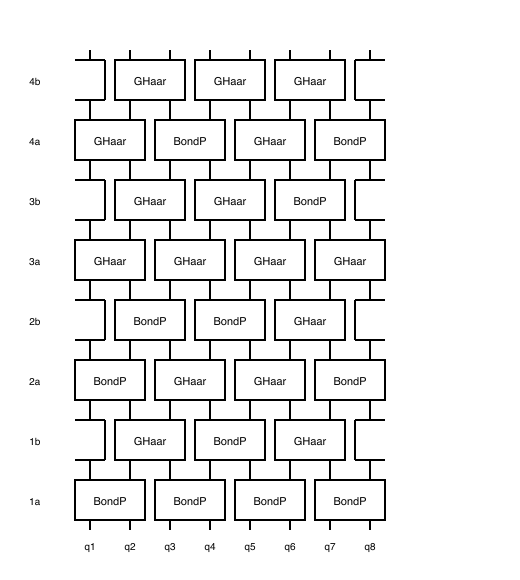

In [4]:
plot_circuit(build_diii_circuit(L=8, p=0.5); gates_spacetime=0, n_steps=4)

## Order parameter

$A = 1..L/4$, $B = L/2{+}1..3L/4$ (antipodal quarters), $I(A,B)$ averaged over all $L/2$ cyclic shifts; shifted regions wrap around the ring (supported by the Gaussian `MutualInformation`). Values in nats.

In [5]:
function antipodal_mi(state; L=state.L)
    A0 = collect(1:(L ÷ 4))
    B0 = collect((L ÷ 2 + 1):(3L ÷ 4))
    vals = Vector{Float64}(undef, L ÷ 2)
    for shift in 0:(L ÷ 2 - 1)
        A = mod1.(A0 .+ shift, L)   # wrapped regions are fine on the Gaussian backend
        B = mod1.(B0 .+ shift, L)
        vals[shift + 1] = MutualInformation(A, B)(state)
    end
    return mean(vals)
end

println("antipodal_mi defined")

antipodal_mi defined


## Single trajectory

MI vs $t$ at $p = 0.5$: saturates by $t \approx L$, hence the sweep depth $t = L$.

Final antipodal MI (t = 2L): 0.4307 nats


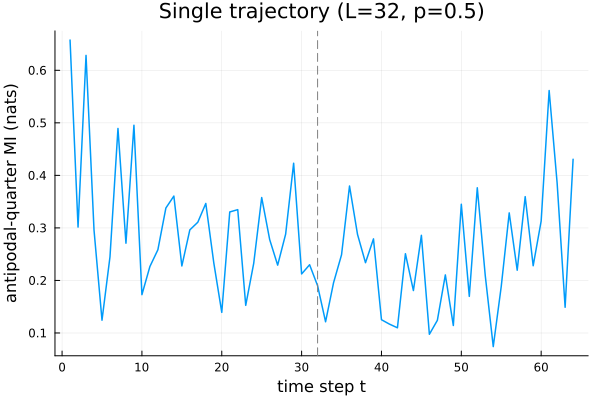

In [6]:
L_demo, p_demo = 32, 0.5
circuit_demo = build_diii_circuit(L=L_demo, p=p_demo)

state_demo = SimulationState(L=L_demo, bc=:periodic, backend=:gaussian, site_type="Majorana",
    rng=RNGRegistry(gates_spacetime=1, born_measurement=2, gates_realization=3, state_init=4))
initialize!(state_demo, RandomGaussianState())   # paper: random Gaussian initial state
track!(state_demo, :mi => (s -> antipodal_mi(s)))

simulate!(circuit_demo, state_demo; n_steps=2 * L_demo, record_when=:every_step)

mi_vals = state_demo.observables[:mi]
println("Final antipodal MI (t = 2L): ", round(mi_vals[end], digits=4), " nats")

plot(1:2*L_demo, mi_vals, xlabel="time step t", ylabel="antipodal-quarter MI (nats)",
     title="Single trajectory (L=$L_demo, p=$p_demo)", legend=false, lw=1.5)
vline!([L_demo], ls=:dash, c=:gray)   # t = L: sweep depth, MI already saturated

## Phase-diagram sweep

`run_diii` tracks the MI with `track!` and records it once via `record_when=:final_only`; each trajectory gets 4 disjoint RNG streams. Run with `julia -t auto` for threading.

In [7]:
function run_diii(; L, p, seed, t=L, bc=:periodic)
    circuit = build_diii_circuit(L=L, p=p, bc=bc)
    state = SimulationState(L=L, bc=bc, backend=:gaussian, site_type="Majorana",
        # 4 disjoint RNG streams per trajectory (mipt_example's offset idiom,
        # widened from 3 to 4 streams since we also draw :state_init)
        rng=RNGRegistry(gates_spacetime=4 * (seed - 1) + 1,
                        born_measurement=4 * (seed - 1) + 2,
                        gates_realization=4 * (seed - 1) + 3,
                        state_init=4 * (seed - 1) + 4))
    initialize!(state, RandomGaussianState())   # paper: random Gaussian initial state
    track!(state, :mi => antipodal_mi)
    simulate!(circuit, state; n_steps=t, record_when=:final_only)
    return state.observables[:mi][end]
end

# Staggering sanity check (negative controls): the two dimerized limits must
# give ~zero antipodal MI, while p = 0.5 (critical) must be far above them.
mi0, mi5, mi1 = (run_diii(L=32, p=p, seed=1) for p in (0.0, 0.5, 1.0))
@printf("MI(p=0) = %.2e   MI(p=0.5) = %.4f   MI(p=1) = %.2e\n", mi0, mi5, mi1)
@assert mi0 < 1e-8 && mi1 < 1e-8 && mi5 > 10 * max(mi0, mi1, 1e-12)
println("Stagger check OK: p=0 and p=1 are area-law dimer states; p=0.5 is critical.")

MI(p=0) = 0.00e+00   MI(p=0.5) = 0.1900   MI(p=1) = -2.22e-15
Stagger check OK: p=0 and p=1 are area-law dimer states; p=0.5 is critical.

In [8]:
configs = [(L=L, p=p, seed=s) for L in L_list for p in p_list for s in 1:n_realizations]
raw = Vector{Float64}(undef, length(configs))

println("Running $(length(configs)) configs on $(Threads.nthreads()) threads...")
@time @showprogress Threads.@threads for i in eachindex(configs)
    c = configs[i]
    raw[i] = run_diii(L=c.L, p=c.p, seed=c.seed)
end

# Reshape to (seed, p, L) and average over seeds
ns, np, nL = n_realizations, length(p_list), length(L_list)
MI_raw = reshape(raw, ns, np, nL)
MI_mean = dropdims(mean(MI_raw, dims=1), dims=1)
MI_sem  = dropdims(std(MI_raw, dims=1), dims=1) ./ sqrt(ns)

println("Done!")

Running 1650 configs on 4 threads...



Progress:   0%|                                         |  ETA: 0:22:22

Progress:  61%|████████████████████████▉                |  ETA: 0:00:07


Progress:  61%|█████████████████████████▏               |  ETA: 0:00:07


Progress:  62%|█████████████████████████▍               |  ETA: 0:00:07

...


Progress:  99%|████████████████████████████████████████▉|  ETA: 0:00:00


Progress:  99%|█████████████████████████████████████████|  ETA: 0:00:00


Progress:  99%|█████████████████████████████████████████|  ETA: 0:00:00

Progress: 100%|█████████████████████████████████████████| Time: 0:04:08

251.099432 seconds (215.00 M allocations: 173.312 GiB, 33.12% gc time, 93 lock conflicts, 3.20% compilation time)
Done!

## Fig. 1b

MI vs $p$, one curve per $L$; dashed lines at the paper's $p_c \approx 0.4,\ 0.6$.

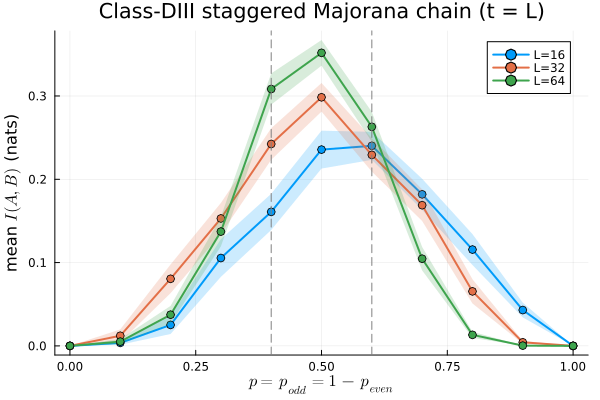

In [9]:
fig = plot(xlabel=raw"$p = p_{\rm odd} = 1 - p_{\rm even}$",
    ylabel=raw"mean $I(A,B)$ (nats)",
    title="Class-DIII staggered Majorana chain (t = L)", legend=:topright)
for (iL, L) in enumerate(L_list)
    plot!(fig, p_list, MI_mean[:, iL], ribbon=MI_sem[:, iL], fillalpha=0.2,
          label="L=$L", lw=2, marker=:o, ms=4)
end
vline!(fig, [0.4, 0.6], ls=:dash, c=:gray, label="")
fig

## Notes

- Full convergence of the crossings needs the paper's $L = 256$ and $\sim 1000$ realizations; this demo uses reduced sizes (~minutes).
- Script mirror: [`examples/gaussian_example.jl`](gaussian_example.jl).